# Chatbot Graph Development Notebook

Each section is independently runnable. Run **Section 1** first to set up paths and verify connectivity, then jump to any section.

| Section | What it covers |
|---------|----------------|
| 1 | Setup, paths, DB + LLM connectivity |
| 2 | `generate_sql` node — prompt tuning |
| 3 | `execute_sql` tool — query testing |
| 4 | Greeting classifier — fix the broken node |
| 5 | `generate_answer` node — response quality |
| 6 | Graph routing — conditional edges + visualization |
| 7 | End-to-end session with checkpointing |

---
## Section 1 — Setup & Connectivity

In [1]:
import os
import sys

# Add the project root so all chatbot.* imports resolve.
PROJECT_ROOT = os.path.abspath(".")  # run from /home/eeshan/Documents/IMDB
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: /home/eeshan/Documents/IMDB


In [2]:
from dotenv import load_dotenv

loaded = load_dotenv(".env.dev")
print("Loaded .env.dev:", loaded)

# Spot-check that the key env vars are present (values hidden)
for var in [
    "DATABASE_URL",
    "OPENAI_API_KEY",
    "ANTHROPIC_API_KEY",
    "LLM_PROVIDER",
    "LLM_MODEL",
]:
    val = os.getenv(var, "")
    status = "OK" if val else "MISSING"
    preview = (val[:6] + "...") if val else ""
    print(f"  {var}: {status} {preview}")

Loaded .env.dev: True
  DATABASE_URL: MISSING 
  OPENAI_API_KEY: OK sk-pro...
  ANTHROPIC_API_KEY: MISSING 
  LLM_PROVIDER: OK openai...
  LLM_MODEL: OK gpt-4o...


In [4]:
# --- DB connectivity ---
from sqlalchemy import text

from db.postgres_session import engine

with engine.connect() as conn:
    row = conn.execute(
        text("SELECT current_database(), current_user, version()")
    ).fetchone()
    print("DB:", row[0], "| User:", row[1])
    print("Version:", row[2][:60])

DB: ingestion_db | User: admin
Version: PostgreSQL 16.14 (Debian 16.14-1.pgdg13+1) on x86_64-pc-linu


In [5]:
# --- Quick table row counts ---
tables = [
    "title_basics",
    "title_ratings",
    "title_akas",
    "title_crew",
    "title_episode",
    "title_principals",
    "name_basics",
]

with engine.connect() as conn:
    for t in tables:
        try:
            n = conn.execute(text(f"SELECT COUNT(*) FROM {t}")).scalar()
            print(f"  {t}: {n:,} rows")
        except Exception as e:
            print(f"  {t}: ERROR — {e}")

  title_basics: 12,502,313 rows
  title_ratings: 1,669,554 rows
  title_akas: 57,069,337 rows
  title_crew: 12,499,798 rows
  title_episode: 9,654,560 rows
  title_principals: 99,436,957 rows
  name_basics: 15,327,170 rows


In [6]:
# --- LLM connectivity ---
from chatbot.api.config import DEFAULT_MODEL, DEFAULT_PROVIDER
from chatbot.api.llm.factory import get_llm

print(f"Default provider: {DEFAULT_PROVIDER}, model: {DEFAULT_MODEL}")

llm = get_llm(DEFAULT_PROVIDER, DEFAULT_MODEL)
pong = await llm.ainvoke("Reply with exactly: pong")
print("LLM response:", pong.content)

Default provider: openai, model: gpt-4o-mini
LLM response: pong


---
## Section 2 — SQL Generation Node

Test the `generate_sql` node in isolation. Change `QUESTION` and re-run to iterate on the system prompt.

In [7]:
from langchain_core.messages import HumanMessage, SystemMessage

from chatbot.api.graph.nodes import _SQL_SYSTEM, _clean_sql
from chatbot.api.graph.schema import SCHEMA

QUESTION = "Who are the top 5 highest-rated movies of all time?"

llm = get_llm(DEFAULT_PROVIDER, DEFAULT_MODEL)
messages = [SystemMessage(content=_SQL_SYSTEM), HumanMessage(content=QUESTION)]
response = await llm.ainvoke(messages)

print("=== Raw LLM output ===")
print(response.content)
print()
print("=== Cleaned SQL ===")
sql = _clean_sql(response.content)
print(sql)

=== Raw LLM output ===
SELECT tb.primary_title, tr.average_rating 
FROM title_basics tb 
JOIN title_ratings tr ON tb.tconst = tr.tconst 
WHERE tb.title_type = 'movie' 
ORDER BY tr.average_rating DESC 
LIMIT 5;

=== Cleaned SQL ===
SELECT tb.primary_title, tr.average_rating 
FROM title_basics tb 
JOIN title_ratings tr ON tb.tconst = tr.tconst 
WHERE tb.title_type = 'movie' 
ORDER BY tr.average_rating DESC 
LIMIT 5;


In [8]:
# Batch-test several questions to spot common failure modes
test_questions = [
    "List all Christopher Nolan movies with their ratings.",
    "Which drama series started after 2010 and have more than 100k votes?",
    "Find actors who appeared in both action and comedy genres.",
    "What is the average runtime of movies released in the 1990s?",
]

for q in test_questions:
    msgs = [SystemMessage(content=_SQL_SYSTEM), HumanMessage(content=q)]
    resp = await llm.ainvoke(msgs)
    sql = _clean_sql(resp.content)
    print(f"Q: {q}")
    print(f"SQL: {sql[:200]}..." if len(sql) > 200 else f"SQL: {sql}")
    print()

Q: List all Christopher Nolan movies with their ratings.
SQL: SELECT tb.primary_title, tr.average_rating 
FROM title_basics tb
JOIN title_ratings tr ON tb.tconst = tr.tconst
JOIN title_principals tp ON tb.tconst = tp.tconst
JOIN name_basics nb ON tp.nconst = nb....

Q: Which drama series started after 2010 and have more than 100k votes?
SQL: SELECT tb.primary_title, tr.average_rating, tr.num_votes
FROM title_basics tb
JOIN title_ratings tr ON tb.tconst = tr.tconst
WHERE tb.title_type = 'tvSeries' 
  AND 'Drama' = ANY(tb.genres) 
  AND tb....

Q: Find actors who appeared in both action and comedy genres.
SQL: SELECT DISTINCT np.primary_name
FROM title_principals tp
JOIN title_basics tb ON tp.tconst = tb.tconst
JOIN name_basics np ON tp.nconst = np.nconst
WHERE 'Action' = ANY(tb.genres) AND 'Comedy' = ANY(t...

Q: What is the average runtime of movies released in the 1990s?
SQL: SELECT AVG(runtime_minutes) AS average_runtime
FROM title_basics
WHERE title_type = 'movie' AND start_year >= 

---
## Section 3 — SQL Execution Tool

Test `execute_sql` directly against the database. No LLM involved.

In [9]:
from chatbot.api.tools.sql_tool import execute_sql

# Paste any SQL here — e.g. from Section 2 output
QUERY = """
SELECT tb.primary_title, tr.average_rating, tr.num_votes
FROM title_basics tb
JOIN title_ratings tr ON tb.tconst = tr.tconst
WHERE tb.title_type = 'movie'
  AND tr.num_votes > 100000
ORDER BY tr.average_rating DESC
LIMIT 10
"""

result = execute_sql(QUERY)
print(result)

[2026-06-19 11:52:17][DEBUG   ][chatbot.api.tools.sql_tool]:	Executing SQL: 
SELECT tb.primary_title, tr.average_rating, tr.num_votes
FROM title_basics tb
JOIN title_ratings tr ON tb.tconst = tr.tconst
WHERE tb.title_type = 'movie'
  AND tr.num_votes > 100000
ORDER BY tr.average_rating DESC
LIMIT 10

[2026-06-19 11:52:17][INFO    ][chatbot.api.tools.sql_tool]:	SQL returned 10 row(s)


primary_title | average_rating | num_votes
------------------------------------------
The Shawshank Redemption | 9.3 | 3188414
The Godfather | 9.2 | 2226027
The Dark Knight | 9.1 | 3167569
Schindler's List | 9.0 | 1585572
The Lord of the Rings: The Return of the King | 9.0 | 2164596
12 Angry Men | 9.0 | 984248
The Godfather Part II | 9.0 | 1495351
The Lord of the Rings: The Fellowship of the Ring | 8.9 | 2206487
Inception | 8.8 | 2816830
The Lord of the Rings: The Two Towers | 8.8 | 1957273


In [10]:
# Error handling — intentionally bad SQL
bad_result = execute_sql("SELECT * FROM nonexistent_table LIMIT 5")
print(bad_result)

[2026-06-19 11:52:37][DEBUG   ][chatbot.api.tools.sql_tool]:	Executing SQL: SELECT * FROM nonexistent_table LIMIT 5
[2026-06-19 11:52:37][ERROR   ][chatbot.api.tools.sql_tool]:	SQL execution failed: (psycopg2.errors.UndefinedTable) relation "nonexistent_table" does not exist
LINE 1: SELECT * FROM nonexistent_table LIMIT 5
                      ^

[SQL: SELECT * FROM nonexistent_table LIMIT 5]
(Background on this error at: https://sqlalche.me/e/20/f405)


SQL Error: (psycopg2.errors.UndefinedTable) relation "nonexistent_table" does not exist
LINE 1: SELECT * FROM nonexistent_table LIMIT 5
                      ^

[SQL: SELECT * FROM nonexistent_table LIMIT 5]
(Background on this error at: https://sqlalche.me/e/20/f405)


In [11]:
# Test array column querying
array_query = """
SELECT primary_title, genres, start_year
FROM title_basics
WHERE 'Drama' = ANY(genres)
  AND 'Comedy' = ANY(genres)
  AND title_type = 'movie'
LIMIT 10
"""
print(execute_sql(array_query))

[2026-06-19 11:52:47][DEBUG   ][chatbot.api.tools.sql_tool]:	Executing SQL: 
SELECT primary_title, genres, start_year
FROM title_basics
WHERE 'Drama' = ANY(genres)
  AND 'Comedy' = ANY(genres)
  AND title_type = 'movie'
LIMIT 10

[2026-06-19 11:52:47][INFO    ][chatbot.api.tools.sql_tool]:	SQL returned 10 row(s)


primary_title | genres | start_year
-----------------------------------
Coupled with Love | ['Comedy', 'Drama'] | 2008
Autumn in My Street | ['Comedy', 'Drama'] | 2009
Woh Ladki Hai Kahaan | ['Comedy', 'Drama'] | NULL
Like an Actress | ['Comedy', 'Drama'] | 2022
Frannie | ['Comedy', 'Drama'] | NULL
Dasvi | ['Comedy', 'Drama'] | 2022
Insomnia! | ['Comedy', 'Drama'] | NULL
Ticket to Paradise | ['Comedy', 'Drama', 'Romance'] | 2022
Hollywood Stargirl | ['Comedy', 'Drama', 'Family'] | 2022
Dad | ['Comedy', 'Drama', 'Romance'] | 2021


---
## Section 4 — Greeting Classifier

The current `greeting` node is broken — it ignores the LLM response and always returns an empty `AIMessage`. This section develops a working replacement.

**Problems in the current code:**
1. `_ANSWER_GREETING_SYSTEM` has `{{user_message}}` placeholder that is never formatted.
2. The LLM call result is unused — always returns `{"messages": [AIMessage(content="")]}`.
3. The conditional edge is commented out in `builder.py`.

In [12]:
import json

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# Corrected system prompt — no {{user_message}} placeholder needed;
# the user's message goes in the HumanMessage instead.
_GREETING_SYSTEM = """You are a message classifier.

Determine whether the user's message is a greeting whose primary intent is to greet or start a conversation.

Return ONLY valid JSON — no markdown, no explanation:
{"is_greeting": true | false, "response": "<friendly reply if greeting, else null>"}
"""


def classify_greeting(message: str, llm) -> dict:
    """Returns {is_greeting: bool, response: str | None}."""
    resp = llm.invoke(
        [
            SystemMessage(content=_GREETING_SYSTEM),
            HumanMessage(content=message),
        ]
    )
    raw = resp.content.strip()
    # Strip markdown fences if the model adds them
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[-1].rsplit("```", 1)[0].strip()
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        # Fallback: treat as non-greeting if we can't parse
        print(f"WARNING: could not parse JSON: {raw!r}")
        return {"is_greeting": False, "response": None}


# Test cases
test_messages = [
    "Hi!",
    "Hello there, how are you?",
    "Good morning!",
    "Who directed Inception?",
    "List the top 10 movies from 2020.",
    "Hey, what's the best sci-fi series?",  # mixed — greeting + question
]

llm = get_llm(DEFAULT_PROVIDER, DEFAULT_MODEL)
for msg in test_messages:
    result = classify_greeting(msg, llm)
    tag = "GREETING" if result["is_greeting"] else "QUESTION"
    reply = result.get("response") or "→ route to SQL"
    print(f"[{tag}] {msg!r}")
    print(f"       {reply}")
    print()

[GREETING] 'Hi!'
       Hello! How can I help you today?

[GREETING] 'Hello there, how are you?'
       I'm doing well, thank you! How about you?

[GREETING] 'Good morning!'
       Good morning! How can I help you today?

[QUESTION] 'Who directed Inception?'
       → route to SQL

[QUESTION] 'List the top 10 movies from 2020.'
       → route to SQL

[QUESTION] "Hey, what's the best sci-fi series?"
       → route to SQL



In [13]:
# Draft the corrected node function
from langchain_core.runnables import RunnableConfig

from chatbot.api.graph.state import ChatState


async def greeting_fixed(state: ChatState, config: RunnableConfig) -> dict:
    """Classify the latest message. If a greeting, respond and set greeted_user=True.
    Returns empty dict on non-greetings so the router can forward to generate_sql.
    """
    cfg = config["configurable"]
    llm = get_llm(cfg["provider"], cfg["model"])

    last_message = state["messages"][-1].content if state["messages"] else ""
    result = classify_greeting(last_message, llm)

    if result["is_greeting"] and result.get("response"):
        return {
            "messages": [AIMessage(content=result["response"])],
            "greeted_user": True,
        }
    return {}  # non-greeting: router will send to generate_sql


# The router function for the conditional edge
def route_after_greeting(state: ChatState) -> str:
    """If the last message is an AIMessage (greeting reply was added), we're done.
    Otherwise route to generate_sql.
    """
    last = state["messages"][-1] if state["messages"] else None
    if isinstance(last, AIMessage):
        return "__end__"
    return "generate_sql"


print("greeting_fixed and route_after_greeting defined.")

greeting_fixed and route_after_greeting defined.


---
## Section 5 — Answer Generation Node

Test `generate_answer` with pre-canned results to iterate on the answer system prompt without needing a live SQL call.

In [14]:
from chatbot.api.graph.nodes import _ANSWER_SYSTEM


async def test_answer(question: str, sql_query: str, sql_results: str):
    llm = get_llm(DEFAULT_PROVIDER, DEFAULT_MODEL)
    context = f"SQL query executed:\n{sql_query}\n\nResults:\n{sql_results}"
    messages = [
        SystemMessage(content=_ANSWER_SYSTEM),
        HumanMessage(content=question),
        HumanMessage(content=f"[Database context]\n{context}"),
    ]
    response = await llm.ainvoke(messages)
    return response.content


# Test 1: normal result
answer = await test_answer(
    question="Who are the top 5 highest-rated movies?",
    sql_query="SELECT primary_title, average_rating FROM title_basics JOIN title_ratings USING (tconst) ORDER BY average_rating DESC LIMIT 5",
    sql_results="primary_title | average_rating\n"
    + "-" * 40
    + "\n"
    + "The Shawshank Redemption | 9.3\n"
    "The Godfather | 9.2\n"
    "The Dark Knight | 9.0\n"
    "The Godfather Part II | 9.0\n"
    "12 Angry Men | 9.0",
)
print("=== Normal result ===")
print(answer)
print()

=== Normal result ===
The top 5 highest-rated movies are:

1. The Shawshank Redemption - 9.3
2. The Godfather - 9.2
3. The Dark Knight - 9.0
4. The Godfather Part II - 9.0
5. 12 Angry Men - 9.0



In [15]:
# Test 2: empty result
answer_empty = await test_answer(
    question="List movies from 1800.",
    sql_query="SELECT primary_title FROM title_basics WHERE start_year = 1800 LIMIT 20",
    sql_results="Query returned no results.",
)
print("=== Empty result ===")
print(answer_empty)
print()

# Test 3: SQL error result
answer_err = await test_answer(
    question="Who starred in Inception?",
    sql_query="SELECT * FROM nonexistent_table LIMIT 5",
    sql_results='SQL Error: relation "nonexistent_table" does not exist',
)
print("=== SQL error result ===")
print(answer_err)

=== Empty result ===
There are no movies from the year 1800 in the provided data.

=== SQL error result ===
There was an error executing the SQL query, and I do not have access to the data you requested. However, I can tell you that the main stars of "Inception" include Leonardo DiCaprio, Joseph Gordon-Levitt, Ellen Page, Tom Hardy, Ken Watanabe, and Marion Cotillard.


---
## Section 6 — Graph Routing & Visualization

Build a corrected version of the graph with the conditional greeting edge wired up, then visualize it.

In [16]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph

from chatbot.api.graph.nodes import generate_answer, generate_sql, run_sql
from chatbot.api.graph.state import ChatState

# greeting_fixed and route_after_greeting defined in Section 4


def build_corrected_graph():
    g = StateGraph(ChatState)

    g.add_node("greeting", greeting_fixed)
    g.add_node("generate_sql", generate_sql)
    g.add_node("run_sql", run_sql)
    g.add_node("generate_answer", generate_answer)

    g.set_entry_point("greeting")

    # Conditional: if greeting → END, else → generate_sql
    g.add_conditional_edges(
        "greeting",
        route_after_greeting,
        {"__end__": END, "generate_sql": "generate_sql"},
    )

    g.add_edge("generate_sql", "run_sql")
    g.add_edge("run_sql", "generate_answer")
    g.add_edge("generate_answer", END)

    return g.compile(checkpointer=MemorySaver())


dev_graph = build_corrected_graph()
print("Graph compiled successfully.")

Graph compiled successfully.


In [17]:
# Visualize as Mermaid diagram (renders in VS Code / JupyterLab with Mermaid extension)
from IPython.display import Markdown, display

mermaid_src = dev_graph.get_graph().draw_mermaid()
display(Markdown(f"```mermaid\n{mermaid_src}\n```"))

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	greeting(greeting)
	generate_sql(generate_sql)
	run_sql(run_sql)
	generate_answer(generate_answer)
	__end__([<p>__end__</p>]):::last
	__start__ --> greeting;
	generate_sql --> run_sql;
	greeting -.-> __end__;
	greeting -.-> generate_sql;
	run_sql --> generate_answer;
	generate_answer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

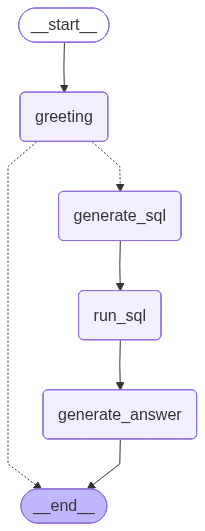

In [18]:
# Render as PNG (requires pygraphviz or pillow)
try:
    from IPython.display import Image

    png = dev_graph.get_graph().draw_mermaid_png()
    display(Image(png))
except Exception as e:
    print(f"PNG render unavailable ({e}). Use the Mermaid cell above instead.")

---
## Section 7 — End-to-End Session

Run the full corrected graph with a persistent `thread_id`. Inspect the `ChatState` at each step.

In [19]:
import uuid

from langchain_core.messages import HumanMessage

THREAD_ID = str(uuid.uuid4())
print(f"Session thread_id: {THREAD_ID}")

CONFIG = {
    "configurable": {
        "thread_id": THREAD_ID,
        "provider": DEFAULT_PROVIDER,
        "model": DEFAULT_MODEL,
    }
}


async def send(message: str, verbose: bool = True):
    """Send a message and print the final answer."""
    input_state = {"messages": [HumanMessage(content=message)]}
    final_state = await dev_graph.ainvoke(input_state, config=CONFIG)

    last = final_state["messages"][-1]
    if verbose:
        print(f"User : {message}")
        print(f"Bot  : {last.content}")
        if final_state.get("sql_query"):
            print(
                f"SQL  : {final_state['sql_query'][:120]}..."
                if len(final_state["sql_query"]) > 120
                else f"SQL  : {final_state['sql_query']}"
            )
        print()
    return final_state


print("send() helper ready.")

Session thread_id: c6c8112e-9e2f-4142-93f0-01ba05df0584
send() helper ready.


In [20]:
# Turn 1: greeting — should NOT call SQL
state1 = await send("Hello!")

User : Hello!
Bot  : Hi there! How can I help you today?



In [21]:
# Turn 2: real question — should generate SQL + answer
state2 = await send("Who directed The Dark Knight?")

[2026-06-19 12:06:05][INFO    ][chatbot.api.graph.nodes]:	[thread:c6c8112e-9e2f-4142-93f0-01ba05df0584] generate_sql — provider=openai model=gpt-4o-mini history_len=3
[2026-06-19 12:06:07][DEBUG   ][chatbot.api.graph.nodes]:	[thread:c6c8112e-9e2f-4142-93f0-01ba05df0584] Generated SQL: SELECT n.primary_name 
FROM title_basics tb 
JOIN title_crew tc ON tb.tconst = tc.tconst 
JOIN name_basics n ON tc.directors[1] = n.nconst 
WHERE tb.primary_title = 'The Dark Knight';
[2026-06-19 12:06:07][INFO    ][chatbot.api.graph.nodes]:	[thread:c6c8112e-9e2f-4142-93f0-01ba05df0584] run_sql — executing query
[2026-06-19 12:06:07][DEBUG   ][chatbot.api.graph.nodes]:	[thread:c6c8112e-9e2f-4142-93f0-01ba05df0584] SQL: SELECT n.primary_name 
FROM title_basics tb 
JOIN title_crew tc ON tb.tconst = tc.tconst 
JOIN name_basics n ON tc.directors[1] = n.nconst 
WHERE tb.primary_title = 'The Dark Knight';
[2026-06-19 12:06:07][DEBUG   ][chatbot.api.tools.sql_tool]:	Executing SQL: SELECT n.primary_name 
FROM tit

User : Who directed The Dark Knight?
Bot  : The results of the query indicate multiple names, but the correct director of "The Dark Knight" is Christopher Nolan.
SQL  : SELECT n.primary_name 
FROM title_basics tb 
JOIN title_crew tc ON tb.tconst = tc.tconst 
JOIN name_basics n ON tc.direc...



In [22]:
# Turn 3: follow-up — tests if conversation history is being preserved
state3 = await send("What other movies has that director made?")

[2026-06-19 12:07:51][INFO    ][chatbot.api.graph.nodes]:	[thread:c6c8112e-9e2f-4142-93f0-01ba05df0584] generate_sql — provider=openai model=gpt-4o-mini history_len=5
[2026-06-19 12:07:53][DEBUG   ][chatbot.api.graph.nodes]:	[thread:c6c8112e-9e2f-4142-93f0-01ba05df0584] Generated SQL: SELECT tb.primary_title 
FROM title_basics tb 
JOIN title_crew tc ON tb.tconst = tc.tconst 
WHERE 'nm0000201' = ANY(tc.directors)  -- Christopher Nolan's nconst
AND tb.title_type = 'movie' 
LIMIT 20;
[2026-06-19 12:07:53][INFO    ][chatbot.api.graph.nodes]:	[thread:c6c8112e-9e2f-4142-93f0-01ba05df0584] run_sql — executing query
[2026-06-19 12:07:53][DEBUG   ][chatbot.api.graph.nodes]:	[thread:c6c8112e-9e2f-4142-93f0-01ba05df0584] SQL: SELECT tb.primary_title 
FROM title_basics tb 
JOIN title_crew tc ON tb.tconst = tc.tconst 
WHERE 'nm0000201' = ANY(tc.directors)  -- Christopher Nolan's nconst
AND tb.title_type = 'movie' 
LIMIT 20;
[2026-06-19 12:07:53][DEBUG   ][chatbot.api.tools.sql_tool]:	Executing SQL:

User : What other movies has that director made?
Bot  : It seems that there are no results returned for the movies directed by Christopher Nolan in the provided database context. Therefore, I cannot provide a list of other movies he has directed.
SQL  : SELECT tb.primary_title 
FROM title_basics tb 
JOIN title_crew tc ON tb.tconst = tc.tconst 
WHERE 'nm0000201' = ANY(tc.d...



In [23]:
# Inspect the full accumulated state for the thread
checkpoint = await dev_graph.aget_state(CONFIG)
print(f"Messages in history: {len(checkpoint.values['messages'])}")
print(f"greeted_user: {checkpoint.values.get('greeted_user')}")
print()
for msg in checkpoint.values["messages"]:
    role = msg.__class__.__name__.replace("Message", "")
    print(
        f"[{role}] {msg.content[:100]}..."
        if len(msg.content) > 100
        else f"[{role}] {msg.content}"
    )

Messages in history: 6
greeted_user: True

[Human] Hello!
[AI] Hi there! How can I help you today?
[Human] Who directed The Dark Knight?
[AI] The results of the query indicate multiple names, but the correct director of "The Dark Knight" is C...
[Human] What other movies has that director made?
[AI] It seems that there are no results returned for the movies directed by Christopher Nolan in the prov...


In [24]:
# Stream events — inspect which nodes fired and in what order
input_state = {
    "messages": [HumanMessage(content="List the top 3 animated movies by rating.")]
}

print("=== Node execution trace ===")
async for event in dev_graph.astream_events(input_state, config=CONFIG, version="v2"):
    if event["event"] in ("on_chain_start", "on_chain_end"):
        node = event["metadata"].get("langgraph_node", "")
        if node:
            status = "START" if event["event"] == "on_chain_start" else "END  "
            print(f"  [{status}] {node}")

=== Node execution trace ===
  [START] greeting


[2026-06-19 12:12:13][INFO    ][chatbot.api.graph.nodes]:	[thread:c6c8112e-9e2f-4142-93f0-01ba05df0584] generate_sql — provider=openai model=gpt-4o-mini history_len=7


  [START] greeting
  [END  ] greeting
  [END  ] greeting
  [START] generate_sql


[2026-06-19 12:12:15][DEBUG   ][chatbot.api.graph.nodes]:	[thread:c6c8112e-9e2f-4142-93f0-01ba05df0584] Generated SQL: SELECT tb.primary_title, tr.average_rating 
FROM title_basics tb 
JOIN title_ratings tr ON tb.tconst = tr.tconst 
WHERE 'Animation' = ANY(tb.genres) 
ORDER BY tr.average_rating DESC 
LIMIT 3;
[2026-06-19 12:12:15][INFO    ][chatbot.api.graph.nodes]:	[thread:c6c8112e-9e2f-4142-93f0-01ba05df0584] run_sql — executing query
[2026-06-19 12:12:15][DEBUG   ][chatbot.api.graph.nodes]:	[thread:c6c8112e-9e2f-4142-93f0-01ba05df0584] SQL: SELECT tb.primary_title, tr.average_rating 
FROM title_basics tb 
JOIN title_ratings tr ON tb.tconst = tr.tconst 
WHERE 'Animation' = ANY(tb.genres) 
ORDER BY tr.average_rating DESC 
LIMIT 3;
[2026-06-19 12:12:15][DEBUG   ][chatbot.api.tools.sql_tool]:	Executing SQL: SELECT tb.primary_title, tr.average_rating 
FROM title_basics tb 
JOIN title_ratings tr ON tb.tconst = tr.tconst 
WHERE 'Animation' = ANY(tb.genres) 
ORDER BY tr.average_rating DESC 

  [END  ] generate_sql
  [START] run_sql


[2026-06-19 12:12:15][INFO    ][chatbot.api.tools.sql_tool]:	SQL returned 3 row(s)
[2026-06-19 12:12:15][INFO    ][chatbot.api.graph.nodes]:	[thread:c6c8112e-9e2f-4142-93f0-01ba05df0584] run_sql — result header: primary_title | average_rating
[2026-06-19 12:12:15][INFO    ][chatbot.api.graph.nodes]:	[thread:c6c8112e-9e2f-4142-93f0-01ba05df0584] generate_answer — provider=openai model=gpt-4o-mini


  [END  ] run_sql
  [START] generate_answer


[2026-06-19 12:12:17][INFO    ][chatbot.api.graph.nodes]:	[thread:c6c8112e-9e2f-4142-93f0-01ba05df0584] generate_answer — answer length=143 chars


  [END  ] generate_answer
